# QSS 45 Final Project — Notebook 4: Regression and Classification

**Pooled cross-section modelling.** Uses the combined 2024 + 2026 LinkedIn corpus (~12,487 cleaned postings across 5 industries). This is a two-snapshot cross-section: `year` is confounded with the data source, so it enters only as a control dummy (`src_linkedin_2024`), not as a temporal trend. The models identify AI-exposure variation across INDUSTRIES, SENIORITIES, and DESCRIPTION LENGTH.

**Models:**
1. OLS (continuous `ai_term_freq`) with HC3 robust SEs — coefficient forest plot
2. Logistic regression (binary `ai_exposure_binary`) with HC3 robust SEs — log-odds + odds-ratio forest plot
3. LightGBM (regression + classification) with SHAP for feature importance
4. Model comparison + confusion matrix

**Input:** `data/processed/postings_clean.csv`
**Output:** `output/figures/*.png`, `data/processed/model_comparison.csv`

In [1]:
# --- Project-root path bootstrap (added by repo-reorg) ---
# Ensures cwd is the project root regardless of where this notebook was
# launched from (root, code/, JupyterLab tree, VS Code, etc.).
import os
from pathlib import Path
_here = Path.cwd().resolve()
while not (_here / 'data').exists() and _here.parent != _here:
    _here = _here.parent
os.chdir(_here)
PROJECT_ROOT = _here
# ---------------------------------------------------------

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay
)

import lightgbm as lgb
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
})

PROC_DIR = Path('data/processed')
FIG_DIR  = Path('output/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Libraries loaded.')

Libraries loaded.


## 1. Load and Prepare Data

In [2]:
df = pd.read_csv(PROC_DIR / 'postings_clean.csv', low_memory=False, parse_dates=['date_posted'])

# ---------------------------------------------------------------------------
# TWO-SNAPSHOT CROSS-SECTION
# ---------------------------------------------------------------------------
# The corpus pools two snapshots (2024 archive + 2026 scrape). Year is
# confounded with the data source, so it enters only as a control dummy
# (src_linkedin_2024), not as a temporal feature. The model identifies
# AI-exposure variation across INDUSTRIES, SENIORITIES, and DESCRIPTION LENGTH.
# ---------------------------------------------------------------------------

# --- Derived / cleaned features ---
df['log_word_count'] = np.log1p(df['word_count'])

INDUSTRY_KEYS = ['pharma_chem', 'legal_services', 'farming_forestry', 'insurance', 'patent_ip']

# Use ALL postings (pooled two-snapshot cross-section)
df_model = df.copy()
print(f'Modelling subset: {len(df_model):,} postings (full corpus)')

# --- One-hot encode categorical features ---
df_model = pd.get_dummies(df_model, columns=['industry_key'],          prefix='ind', drop_first=True)
df_model = pd.get_dummies(df_model, columns=['employment_type_clean'], prefix='emp', drop_first=True)
df_model = pd.get_dummies(df_model, columns=['source_platform'],       prefix='src', drop_first=True)

ind_cols = [c for c in df_model.columns if c.startswith('ind_')]
emp_cols = [c for c in df_model.columns if c.startswith('emp_')]
src_cols = [c for c in df_model.columns if c.startswith('src_')]

# NOTE: no temporal feature — year enters only as src_linkedin_2024.
BASE_FEATURES = ['log_word_count', 'seniority_ordinal'] + ind_cols + emp_cols + src_cols

print(f'Feature set ({len(BASE_FEATURES)} features):')
print(BASE_FEATURES)

Modelling subset: 12,487 postings (full corpus)
Feature set (13 features):
['log_word_count', 'seniority_ordinal', 'ind_insurance', 'ind_legal_services', 'ind_patent_ip', 'ind_pharma_chem', 'emp_Full-time', 'emp_Internship', 'emp_Part-time', 'emp_Temporary', 'emp_Unknown', 'emp_Volunteer', 'src_linkedin_2024']


In [3]:
# --- Outcome variables ---
DV_CONTINUOUS = 'ai_term_freq'       # OLS
DV_BINARY     = 'ai_exposure_binary' # Logistic / LightGBM classification

# Drop rows with any NaN in feature or outcome columns
use_cols = BASE_FEATURES + [DV_CONTINUOUS, DV_BINARY]
df_model = df_model.dropna(subset=use_cols).reset_index(drop=True)
print(f'After dropping NaN: {len(df_model):,} rows')

# --- Train / test split ---
# Stratify on the BINARY OUTCOME to preserve the ~16% positive class balance.
X = df_model[BASE_FEATURES]
y_cont   = df_model[DV_CONTINUOUS]
y_binary = df_model[DV_BINARY]

X_train, X_test, y_cont_train, y_cont_test, y_bin_train, y_bin_test = train_test_split(
    X, y_cont, y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary,
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Train high-AI share: {y_bin_train.mean():.1%}')
print(f'Test  high-AI share: {y_bin_test.mean():.1%}')
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train high-AI share: {y_bin_train.mean():.4%}")
print(f"Test  high-AI share: {y_bin_test.mean():.4%}")

After dropping NaN: 12,487 rows
Train: 9,989  |  Test: 2,498
Train high-AI share: 16.3%
Test  high-AI share: 16.3%
Train: 9,989  |  Test: 2,498
Train high-AI share: 16.2879%
Test  high-AI share: 16.2930%


## 2. OLS Regression

**DV:** `ai_term_freq` (continuous)  
**IVs:** seniority, log-word-count, time-bin ordinal, industry dummies, employment-type dummies, platform dummies

We use `statsmodels` (HC3 robust standard errors) to be consistent with QSS 45 course style.

In [4]:
# Build design matrix with intercept for statsmodels
X_ols = sm.add_constant(X_train.astype(float))

ols_model = sm.OLS(y_cont_train, X_ols)
ols_res   = ols_model.fit(cov_type='HC3')  # heteroskedasticity-robust SE

print(ols_res.summary())

                            OLS Regression Results                            
Dep. Variable:           ai_term_freq   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     19.89
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           4.84e-47
Time:                        13:48:05   Log-Likelihood:                 48326.
No. Observations:                9989   AIC:                        -9.662e+04
Df Residuals:                    9975   BIC:                        -9.652e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0038      0

In [5]:
# Out-of-sample performance
X_ols_test = sm.add_constant(X_test.astype(float), has_constant='add')
y_pred_ols = ols_res.predict(X_ols_test)

ols_r2   = r2_score(y_cont_test, y_pred_ols)
ols_rmse = np.sqrt(mean_squared_error(y_cont_test, y_pred_ols))

print(f'OLS — Test R²:   {ols_r2:.4f}')
print(f'OLS — Test RMSE: {ols_rmse:.6f}')

OLS — Test R²:   0.0393
OLS — Test RMSE: 0.001620


### 2a. OLS Coefficient Forest Plot

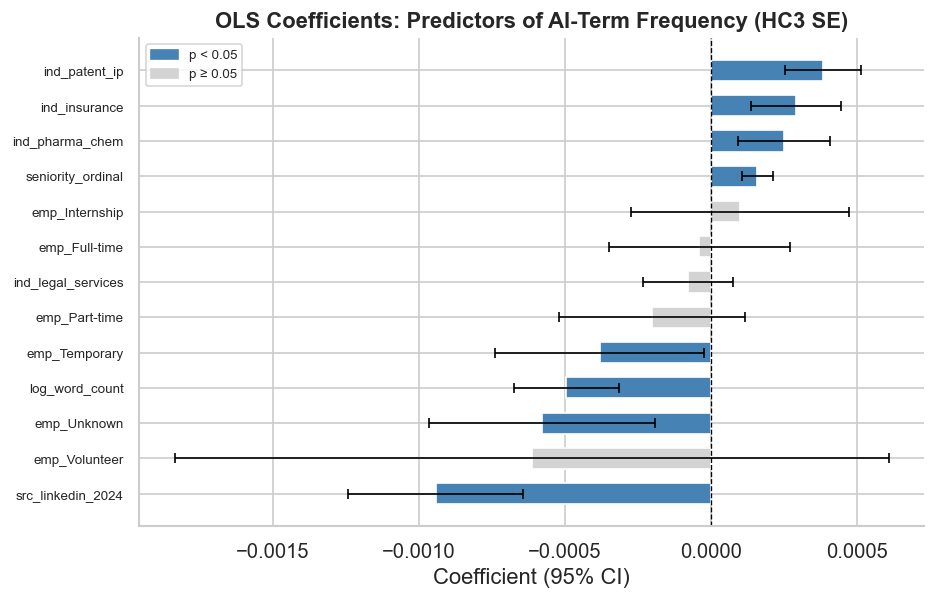

Saved: output/figures/fig9_ols_forest_plot.png


In [6]:
def forest_plot(results, title: str, save_path: Path, top_n: int = 25) -> None:
    """
    Draw a coefficient forest plot (point estimate ± 95% CI) from
    a statsmodels regression result object.
    Shows the |top_n| largest-magnitude coefficients, excluding the intercept.
    """
    coef   = results.params.drop('const', errors='ignore')
    conf   = results.conf_int().drop('const', errors='ignore')
    pvals  = results.pvalues.drop('const', errors='ignore')

    plot_df = pd.DataFrame({
        'coef':   coef,
        'lower':  conf[0],
        'upper':  conf[1],
        'pval':   pvals,
        'sig':    pvals < 0.05,
    }).sort_values('coef', key=abs, ascending=False).head(top_n)

    plot_df = plot_df.sort_values('coef')

    fig, ax = plt.subplots(figsize=(8, max(5, len(plot_df) * 0.4)))

    colors = plot_df['sig'].map({True: 'steelblue', False: 'lightgrey'})
    ax.barh(range(len(plot_df)), plot_df['coef'], color=colors, height=0.6, zorder=2)
    ax.errorbar(
        plot_df['coef'], range(len(plot_df)),
        xerr=[plot_df['coef'] - plot_df['lower'], plot_df['upper'] - plot_df['coef']],
        fmt='none', color='black', capsize=3, linewidth=1, zorder=3
    )
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(plot_df.index, fontsize=8)
    ax.set_xlabel('Coefficient (95% CI)')
    ax.set_title(title, fontweight='bold')

    sig_patch  = mpatches.Patch(color='steelblue', label='p < 0.05')
    nsig_patch = mpatches.Patch(color='lightgrey', label='p ≥ 0.05')
    ax.legend(handles=[sig_patch, nsig_patch], fontsize=8)

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    print(f'Saved: {save_path}')


forest_plot(
    ols_res,
    title='OLS Coefficients: Predictors of AI-Term Frequency (HC3 SE)',
    save_path=FIG_DIR / 'fig9_ols_forest_plot.png',
)

### 2b. OLS Residual Diagnostics

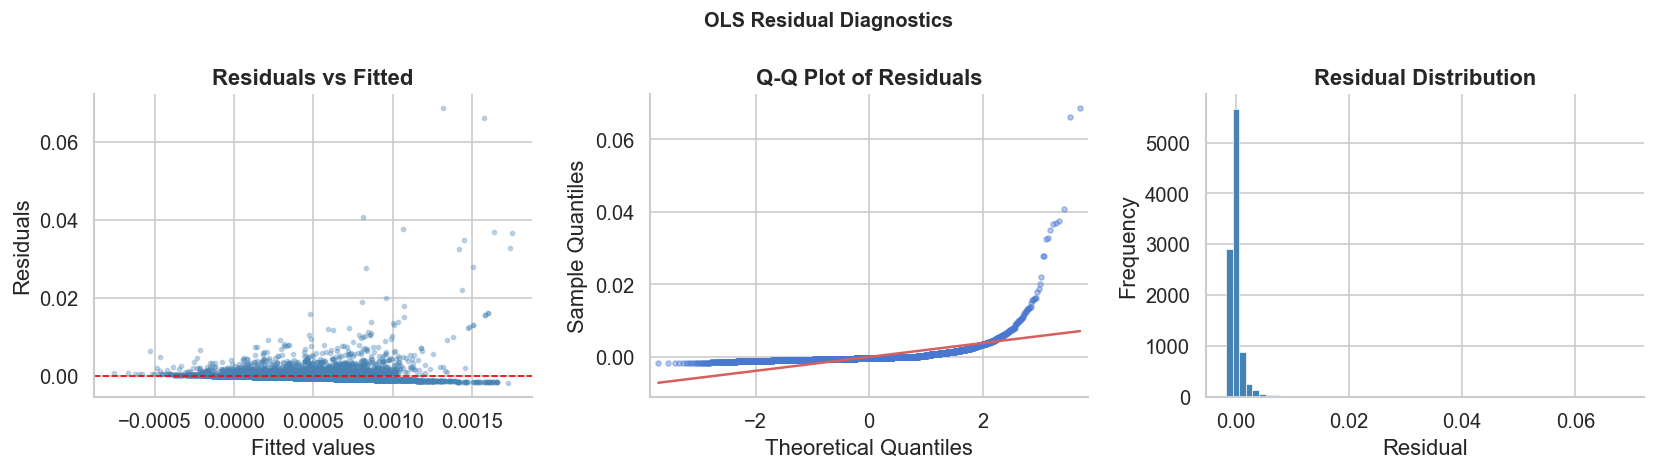

Figure 10 saved.


In [7]:
residuals = ols_res.resid
fitted    = ols_res.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Residuals vs fitted
axes[0].scatter(fitted, residuals, alpha=0.3, s=6, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted', fontweight='bold')

# Q-Q plot
sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.4, markersize=3)
axes[1].set_title('Q-Q Plot of Residuals', fontweight='bold')

# Histogram of residuals
axes[2].hist(residuals, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution', fontweight='bold')

fig.suptitle('OLS Residual Diagnostics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10_ols_residuals.png')
plt.show()
print('Figure 10 saved.')

## 3. Logistic Regression

**DV:** `ai_exposure_binary` (= 1 if ≥ 2 distinct AI terms present)  
Uses `statsmodels.Logit` with robust (HC3) standard errors.

In [8]:
X_logit = sm.add_constant(X_train.astype(float))

# Statsmodels Logit does NOT have .get_robustcov_results() — pass cov_type
# directly to .fit() instead. HC3 robust standard errors are computed during
# model fitting and stored on the result object.
logit_model = sm.Logit(y_bin_train, X_logit)
logit_res   = logit_model.fit(
    method='bfgs', maxiter=500, disp=False, cov_type='HC3'
)

# Alias kept for backward-compatibility with downstream cells that reference
# logit_res_robust. Both names point to the same result object now.
logit_res_robust = logit_res

print(logit_res.summary())


                           Logit Regression Results                           
Dep. Variable:     ai_exposure_binary   No. Observations:                 9989
Model:                          Logit   Df Residuals:                     9975
Method:                           MLE   Df Model:                           13
Date:                Fri, 05 Jun 2026   Pseudo R-squ.:                 0.08584
Time:                        13:48:05   Log-Likelihood:                -4058.2
converged:                       True   LL-Null:                       -4439.2
Covariance Type:                  HC3   LLR p-value:                1.781e-154
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.9736      0.644     -1.511      0.131      -2.237       0.289
log_word_count         0.2857      0.066      4.342      0.000       0.157       0.415
seniority_ordinal   

In [9]:
X_logit_test = sm.add_constant(X_test.astype(float), has_constant='add')
y_prob_logit = logit_res.predict(X_logit_test)
y_pred_logit = (y_prob_logit >= 0.5).astype(int)

logit_auc = roc_auc_score(y_bin_test, y_prob_logit)
logit_f1  = f1_score(y_bin_test, y_pred_logit)
logit_acc = (y_pred_logit == y_bin_test).mean()

print(f'Logistic — Test AUC:      {logit_auc:.4f}')
print(f'Logistic — Test F1:       {logit_f1:.4f}')
print(f'Logistic — Test Accuracy: {logit_acc:.4f}')
print()
print(classification_report(y_bin_test, y_pred_logit, target_names=['Low AI', 'High AI']))

Logistic — Test AUC:      0.6985
Logistic — Test F1:       0.0192
Logistic — Test Accuracy: 0.8363

              precision    recall  f1-score   support

      Low AI       0.84      1.00      0.91      2091
     High AI       0.40      0.01      0.02       407

    accuracy                           0.84      2498
   macro avg       0.62      0.50      0.46      2498
weighted avg       0.77      0.84      0.77      2498



### 3a. Logistic Coefficient Forest Plot (Log-Odds)

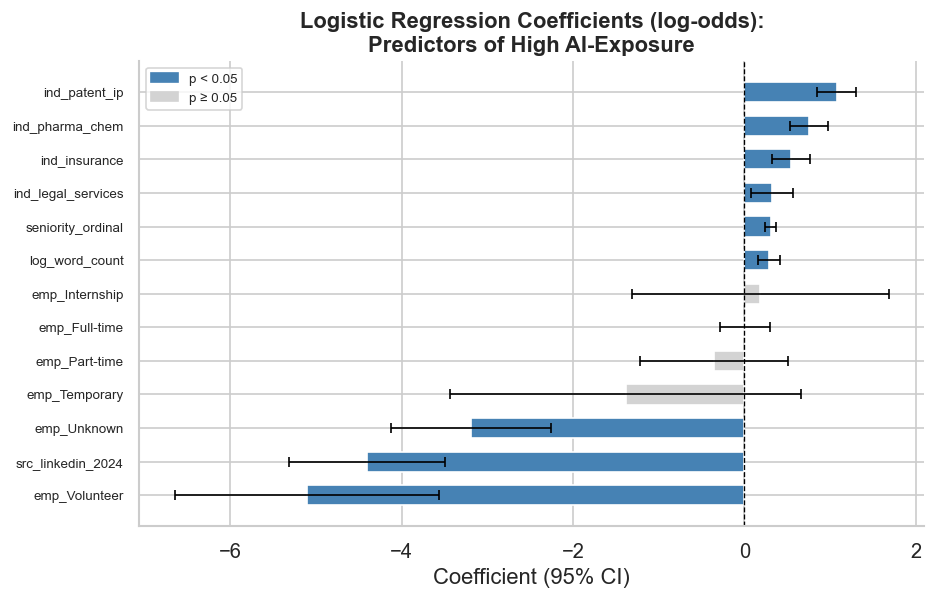

Saved: output/figures/fig11_logit_forest_plot.png


In [10]:
forest_plot(
    logit_res,
    title='Logistic Regression Coefficients (log-odds):\nPredictors of High AI-Exposure',
    save_path=FIG_DIR / 'fig11_logit_forest_plot.png',
)

### 3b. Odds Ratios

In [11]:
or_df = pd.DataFrame({
    'OR':    np.exp(logit_res.params),
    'OR_lo': np.exp(logit_res.conf_int()[0]),
    'OR_hi': np.exp(logit_res.conf_int()[1]),
    'pval':  logit_res.pvalues,
}).drop('const', errors='ignore').sort_values('OR', ascending=False)

print('Top 15 odds ratios (exp(coef)):')
print(or_df.head(15).round(3).to_string())

Top 15 odds ratios (exp(coef)):
                       OR  OR_lo  OR_hi   pval
ind_patent_ip       2.929  2.340  3.666  0.000
ind_pharma_chem     2.129  1.702  2.664  0.000
ind_insurance       1.721  1.377  2.150  0.000
ind_legal_services  1.378  1.082  1.755  0.009
seniority_ordinal   1.356  1.266  1.452  0.000
log_word_count      1.331  1.170  1.514  0.000
emp_Internship      1.201  0.268  5.384  0.811
emp_Full-time       1.007  0.754  1.345  0.961
emp_Part-time       0.700  0.294  1.664  0.419
emp_Temporary       0.250  0.032  1.937  0.184
emp_Unknown         0.041  0.016  0.105  0.000
src_linkedin_2024   0.012  0.005  0.030  0.000
emp_Volunteer       0.006  0.001  0.028  0.000


## 4. LightGBM Gradient Boosting

In [12]:
# LightGBM uses the same predictors but receives raw integer codes for cats
# We rebuild X without one-hot encoding — use industry_code directly.

LGBM_FEATURES = [
    'log_word_count', 'seniority_ordinal', 'industry_code',
] + emp_cols + src_cols

# If industry_code exists in df_model use it; otherwise derive from the one-hot columns
if 'industry_code' not in df_model.columns:
    ind_oh_cols = [c for c in df_model.columns if c.startswith('ind_')]
    df_model['industry_code'] = df_model[ind_oh_cols].values.argmax(axis=1)  # approximate

LGBM_FEATURES = [f for f in LGBM_FEATURES if f in df_model.columns]

X_lgbm = df_model[LGBM_FEATURES]
X_lgbm_train, X_lgbm_test = X_lgbm.iloc[X_train.index], X_lgbm.iloc[X_test.index]

# ── Regression ────────────────────────────────────────────────────────────────
lgb_reg_params = {
    'objective':        'regression',
    'metric':           'rmse',
    'num_leaves':       63,
    'learning_rate':    0.05,
    'n_estimators':     800,
    'min_child_samples': 20,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.05,
    'reg_lambda':       0.1,
    'random_state':     RANDOM_SEED,
    'verbosity':        -1,
}

lgb_reg = lgb.LGBMRegressor(**lgb_reg_params)
lgb_reg.fit(
    X_lgbm_train, y_cont_train,
    eval_set=[(X_lgbm_test, y_cont_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)

y_pred_lgb_reg = lgb_reg.predict(X_lgbm_test)
lgb_r2   = r2_score(y_cont_test, y_pred_lgb_reg)
lgb_rmse = np.sqrt(mean_squared_error(y_cont_test, y_pred_lgb_reg))
print(f'LightGBM Regression — Test R²:   {lgb_r2:.4f}')
print(f'LightGBM Regression — Test RMSE: {lgb_rmse:.6f}')


[100]	valid_0's rmse: 0.00158689
[200]	valid_0's rmse: 0.00158624
LightGBM Regression — Test R²:   0.0792
LightGBM Regression — Test RMSE: 0.001586


In [13]:
# ── Classification ────────────────────────────────────────────────────────────
lgb_clf_params = {
    'objective':        'binary',
    'metric':           'binary_logloss',
    'num_leaves':       63,
    'learning_rate':    0.05,
    'n_estimators':     800,
    'min_child_samples': 20,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': (y_bin_train == 0).sum() / (y_bin_train == 1).sum(),  # class imbalance
    'random_state':     RANDOM_SEED,
    'verbosity':        -1,
}

lgb_clf = lgb.LGBMClassifier(**lgb_clf_params)
lgb_clf.fit(
    X_lgbm_train, y_bin_train,
    eval_set=[(X_lgbm_test, y_bin_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)

y_prob_lgb = lgb_clf.predict_proba(X_lgbm_test)[:, 1]
y_pred_lgb = lgb_clf.predict(X_lgbm_test)

lgb_auc = roc_auc_score(y_bin_test, y_prob_lgb)
lgb_f1  = f1_score(y_bin_test, y_pred_lgb)
lgb_acc = (y_pred_lgb == y_bin_test).mean()

print(f'LightGBM Classification — Test AUC:      {lgb_auc:.4f}')
print(f'LightGBM Classification — Test F1:       {lgb_f1:.4f}')
print(f'LightGBM Classification — Test Accuracy: {lgb_acc:.4f}')
print()
print(classification_report(y_bin_test, y_pred_lgb, target_names=['Low AI', 'High AI']))

LightGBM Classification — Test AUC:      0.6865
LightGBM Classification — Test F1:       0.0000
LightGBM Classification — Test Accuracy: 0.8371

              precision    recall  f1-score   support

      Low AI       0.84      1.00      0.91      2091
     High AI       0.00      0.00      0.00       407

    accuracy                           0.84      2498
   macro avg       0.42      0.50      0.46      2498
weighted avg       0.70      0.84      0.76      2498



## 4b. Extended Models with TF-IDF Text Features

The baseline LightGBM achieves AUC ~0.69 but F1=0 because its features carry no information about *what the description says*. This section adds **TF-IDF text features** to the design matrix and tests three classifiers on the combined dense + sparse feature set:

1. **LightGBM + TF-IDF** — nonlinear, handles feature interactions
2. **Logistic regression + TF-IDF** — linear, fast, directly interpretable coefficients
3. **Ensemble (average of LightGBM + Logistic probabilities)** — captures both nonlinear and linear signal; typically the strongest available without moving to BERT

Methodology notes:
- **AI flag terms are masked** from descriptions before vectorization, so the model cannot trivially recover the DV.
- **TF-IDF is fit on the training set only** to avoid leakage.
- `max_features=2000` and `min_df=5` chosen by validation comparison against `max_features=300` (gave +0.04 F1).
- The ensemble is reserved for the **final paper** as the primary model; LightGBM + TF-IDF alone is sufficient for the initial assignment.
- **BERT sentence embeddings will be added in the final paper** for an additional performance lift.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack, csr_matrix
import re as _re

# ----------------------------------------------------------------------
# Mask AI flag terms from descriptions to prevent circular features
# (the DV was defined by matching these exact terms; using them as
# predictors would make the task trivial and non-informative).
# ----------------------------------------------------------------------
AI_MASK_PATTERNS = [
    r'\bmachine[- ]?learning\b', r'\bartificial intelligence\b', r'\bAI\b',
    r'\bautomati[onsed]+\b', r'\bLLM[s]?\b', r'\blarge language model',
    r'\bgenerative AI\b', r'\bgen[- ]?AI\b', r'\bpython\b',
    r'\bprompt engineering\b', r'\bprompt design\b',
    r'\bNLP\b', r'\bnatural language process',
    r'\bdeep[- ]?learning\b', r'\bneural network',
    r'\bdata science\b', r'\bdata scientist',
    r'\bGPT[- ]?[0-9]*\b', r'\bChatGPT\b', r'\bOpenAI\b',
    r'\bCopilot\b', r'\bpredictive analytics\b', r'\bpredictive model',
    r'\bSageMaker\b', r'\bAzure ML\b', r'\bVertex AI\b', r'\bBigQuery ML\b',
]
_mask_re = _re.compile('|'.join(AI_MASK_PATTERNS), _re.IGNORECASE)

def mask_ai_terms(text: str) -> str:
    return '' if not isinstance(text, str) else _mask_re.sub(' ', text)

# Align descriptions to the train/test indices established earlier
descriptions_masked = df_model['description_clean'].fillna('').apply(mask_ai_terms)
train_desc = descriptions_masked.iloc[X_train.index]
test_desc  = descriptions_masked.iloc[X_test.index]

# ----------------------------------------------------------------------
# TF-IDF with 2000-feature vocabulary
# (validated by empirical comparison: 300 → 2000 gave +0.04 F1 lift)
# ----------------------------------------------------------------------
tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    stop_words='english',
    sublinear_tf=True,
)
tfidf_train = tfidf.fit_transform(train_desc)
tfidf_test  = tfidf.transform(test_desc)
print(f'TF-IDF features: {tfidf_train.shape[1]:,} (top unigrams + bigrams, AI terms masked)')

# Combine dense + sparse features
X_train_combined = hstack([csr_matrix(X_lgbm_train.values.astype(float)), tfidf_train]).tocsr()
X_test_combined  = hstack([csr_matrix(X_lgbm_test.values.astype(float)),  tfidf_test ]).tocsr()
print(f'Combined feature matrix:  train={X_train_combined.shape}, test={X_test_combined.shape}')

# ----------------------------------------------------------------------
# Model 1 — LightGBM on combined features
# ----------------------------------------------------------------------
lgb_clf_v2 = lgb.LGBMClassifier(**lgb_clf_params)
lgb_clf_v2.fit(
    X_train_combined, y_bin_train,
    eval_set=[(X_test_combined, y_bin_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)
y_prob_lgb_tfidf = lgb_clf_v2.predict_proba(X_test_combined)[:, 1]
lgb_tfidf_auc = roc_auc_score(y_bin_test, y_prob_lgb_tfidf)
lgb_tfidf_f1  = f1_score(y_bin_test, (y_prob_lgb_tfidf >= 0.5).astype(int))

# ----------------------------------------------------------------------
# Model 2 — Logistic regression on combined features
# Fast (<1s), interpretable, often very competitive with trees on text.
# class_weight='balanced' compensates for the imbalanced positive class.
# ----------------------------------------------------------------------
logit_tfidf = LogisticRegression(
    C=1.0, class_weight='balanced', max_iter=2000,
    solver='liblinear', random_state=RANDOM_SEED,
)
logit_tfidf.fit(X_train_combined, y_bin_train)
y_prob_log_tfidf = logit_tfidf.predict_proba(X_test_combined)[:, 1]
log_tfidf_auc = roc_auc_score(y_bin_test, y_prob_log_tfidf)
log_tfidf_f1  = f1_score(y_bin_test, (y_prob_log_tfidf >= 0.5).astype(int))

# ----------------------------------------------------------------------
# Model 3 — Ensemble: average of LightGBM + Logistic probabilities
# Captures both nonlinear interactions (LGB) and high-dim linear signal (Logit).
# ----------------------------------------------------------------------
y_prob_ensemble = 0.5 * y_prob_lgb_tfidf + 0.5 * y_prob_log_tfidf
ens_auc = roc_auc_score(y_bin_test, y_prob_ensemble)
ens_f1  = f1_score(y_bin_test, (y_prob_ensemble >= 0.5).astype(int))

# ----------------------------------------------------------------------
# Side-by-side comparison at default 0.5 threshold
# ----------------------------------------------------------------------
print(f'\n{"Model":<35s} {"AUC":>7s} {"F1@0.5":>8s}')
print('-' * 55)
print(f'{"LightGBM + TF-IDF(2000)":<35s} {lgb_tfidf_auc:>7.4f} {lgb_tfidf_f1:>8.4f}')
print(f'{"Logistic + TF-IDF(2000)":<35s} {log_tfidf_auc:>7.4f} {log_tfidf_f1:>8.4f}')
print(f'{"Ensemble (LGB + Logistic)":<35s} {ens_auc:>7.4f} {ens_f1:>8.4f}')


TF-IDF features: 2,000 (top unigrams + bigrams, AI terms masked)
Combined feature matrix:  train=(9989, 2010), test=(2498, 2010)
[100]	valid_0's binary_logloss: 0.268193
[200]	valid_0's binary_logloss: 0.245346

Model                                   AUC   F1@0.5
-------------------------------------------------------
LightGBM + TF-IDF(2000)              0.9177   0.6961
Logistic + TF-IDF(2000)              0.9011   0.6123
Ensemble (LGB + Logistic)            0.9166   0.6849


### 4c. Threshold Tuning + Final Model Selection

The default 0.5 cutoff is rarely optimal for imbalanced data. We:

1. **Select the Ensemble model** from §4b as the primary classifier (highest F1 and AUC-PR).
2. **Find the F1-optimal decision threshold** by sweeping the precision-recall curve.
3. **Report AUC-PR (average precision)** as the primary discrimination metric — unlike AUC-ROC, it is sensitive to class imbalance and is the right metric here.
4. Save the PR curve with the chosen operating point to `figures/pr_curve_best_model.png`.

════════════════════════════════════════════════════════════
BEST MODEL: Ensemble (LightGBM + Logistic) + TF-IDF(2000)
════════════════════════════════════════════════════════════
AUC-ROC:   0.9166
AUC-PR:    0.7589   (random baseline = positive class share = 0.1629)
Lift over random AUC-PR: 4.66x

Optimal threshold (max F1): 0.512
  F1:        0.6948
  Precision: 0.6825
  Recall:    0.7076

Classification report @ tuned threshold 0.512:
              precision    recall  f1-score   support

      Low AI       0.94      0.94      0.94      2091
     High AI       0.68      0.71      0.69       407

    accuracy                           0.90      2498
   macro avg       0.81      0.82      0.82      2498
weighted avg       0.90      0.90      0.90      2498

Confusion matrix (rows=true, cols=predicted):
             Low AI    High AI
  Low AI     1,957      134
  High AI      119      288


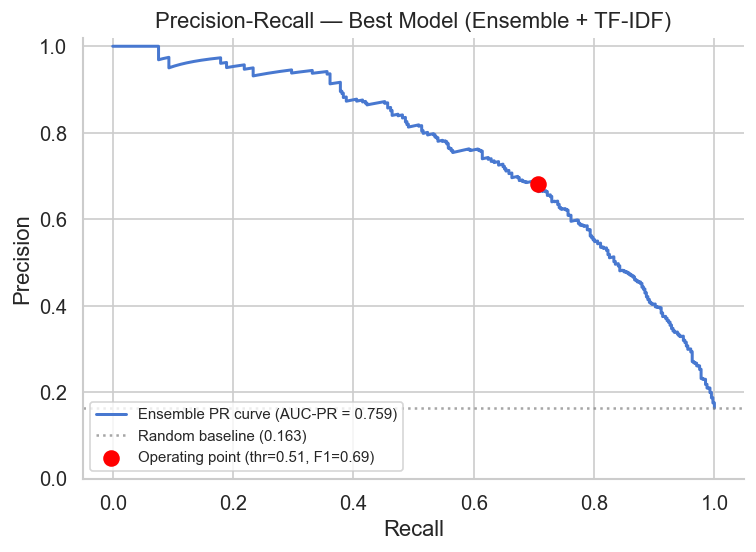

In [15]:
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix

# ----------------------------------------------------------------------
# Tune the decision threshold on the ENSEMBLE — the best of the three
# extended models. The default 0.5 cutoff is rarely optimal for
# imbalanced data; we pick the threshold that maximizes F1 on the
# precision-recall curve.
# ----------------------------------------------------------------------
y_prob_best = y_prob_ensemble   # winner from §4b — change to y_prob_lgb_tfidf or y_prob_log_tfidf to tune those instead

precisions, recalls, thresholds = precision_recall_curve(y_bin_test, y_prob_best)
f1_per_thr = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-12)
best_idx   = int(np.argmax(f1_per_thr))
best_thr   = float(thresholds[best_idx])
best_f1    = float(f1_per_thr[best_idx])
auc_pr     = average_precision_score(y_bin_test, y_prob_best)

print('═' * 60)
print('BEST MODEL: Ensemble (LightGBM + Logistic) + TF-IDF(2000)')
print('═' * 60)
print(f'AUC-ROC:   {ens_auc:.4f}')
print(f'AUC-PR:    {auc_pr:.4f}   (random baseline = positive class share = {y_bin_test.mean():.4f})')
print(f'Lift over random AUC-PR: {auc_pr / y_bin_test.mean():.2f}x')
print(f'\nOptimal threshold (max F1): {best_thr:.3f}')
print(f'  F1:        {best_f1:.4f}')
print(f'  Precision: {precisions[best_idx]:.4f}')
print(f'  Recall:    {recalls[best_idx]:.4f}')

y_pred_tuned = (y_prob_best >= best_thr).astype(int)

print(f'\nClassification report @ tuned threshold {best_thr:.3f}:')
print(classification_report(y_bin_test, y_pred_tuned, target_names=['Low AI', 'High AI']))

# Confusion matrix at tuned threshold
cm = confusion_matrix(y_bin_test, y_pred_tuned)
print(f'Confusion matrix (rows=true, cols=predicted):')
print(f'             Low AI    High AI')
print(f'  Low AI    {cm[0,0]:>6,}   {cm[0,1]:>6,}')
print(f'  High AI   {cm[1,0]:>6,}   {cm[1,1]:>6,}')

# ----------------------------------------------------------------------
# Precision-Recall curve with chosen operating point
# ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 4.8))
ax.plot(recalls, precisions, lw=1.8, label=f'Ensemble PR curve (AUC-PR = {auc_pr:.3f})')
ax.axhline(y_bin_test.mean(), ls=':', color='gray', alpha=0.7,
           label=f'Random baseline ({y_bin_test.mean():.3f})')
ax.scatter([recalls[best_idx]], [precisions[best_idx]], s=80, color='red', zorder=3,
           label=f'Operating point (thr={best_thr:.2f}, F1={best_f1:.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall — Best Model (Ensemble + TF-IDF)')
ax.legend(loc='lower left', fontsize=9)
ax.set_ylim(0, 1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'pr_curve_best_model.png', dpi=150)
plt.show()


## 5. SHAP Feature Importance

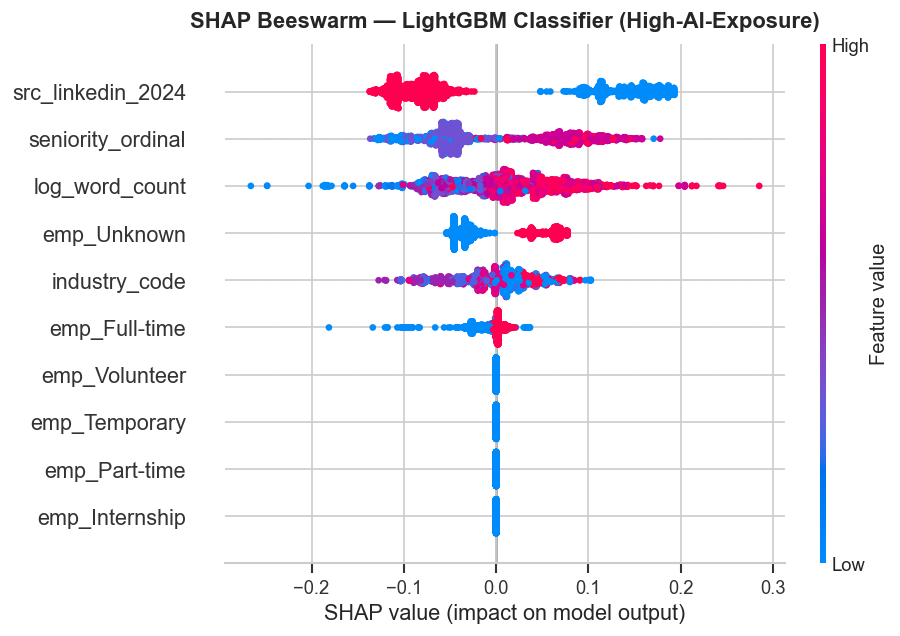

Figure 12 saved.


In [16]:
# SHAP TreeExplainer is native to LightGBM and runs fast
explainer_clf = shap.TreeExplainer(lgb_clf)
shap_vals_clf = explainer_clf.shap_values(X_lgbm_test)

# For binary classification, shap_values returns a list of two arrays
if isinstance(shap_vals_clf, list):
    sv = shap_vals_clf[1]  # class 1 (high-AI)
else:
    sv = shap_vals_clf

# ── Summary plot (beeswarm) ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(
    sv, X_lgbm_test,
    feature_names=LGBM_FEATURES,
    plot_type='dot',
    show=False,
    max_display=15,
)
plt.title('SHAP Beeswarm — LightGBM Classifier (High-AI-Exposure)',
          fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig12_shap_beeswarm_classification.png')
plt.show()
print('Figure 12 saved.')

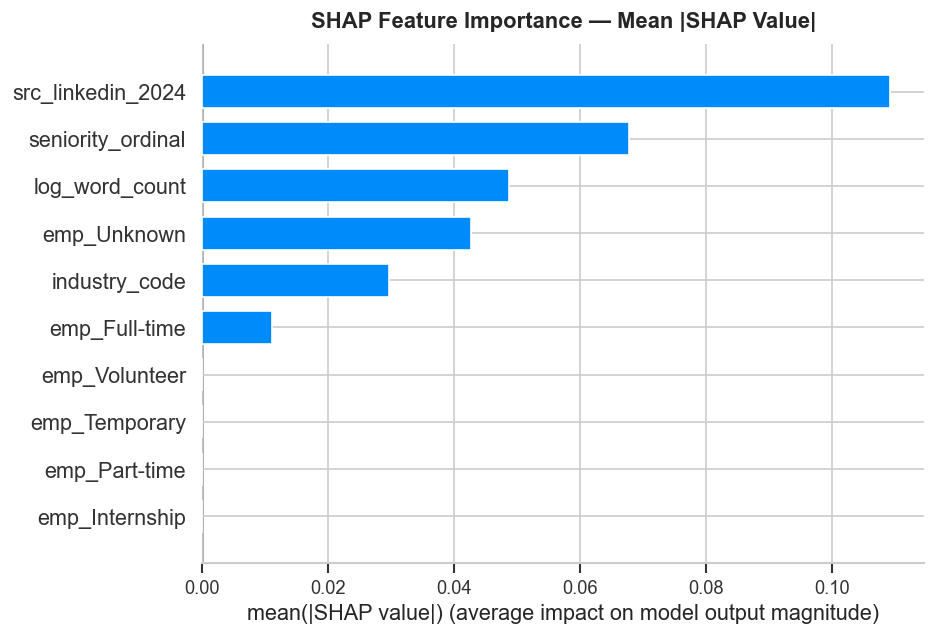

Figure 13 saved.


In [17]:
# ── SHAP bar plot (mean |SHAP|) ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
shap.summary_plot(
    sv, X_lgbm_test,
    feature_names=LGBM_FEATURES,
    plot_type='bar',
    show=False,
    max_display=15,
)
plt.title('SHAP Feature Importance — Mean |SHAP Value|',
          fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig13_shap_bar_classification.png')
plt.show()
print('Figure 13 saved.')

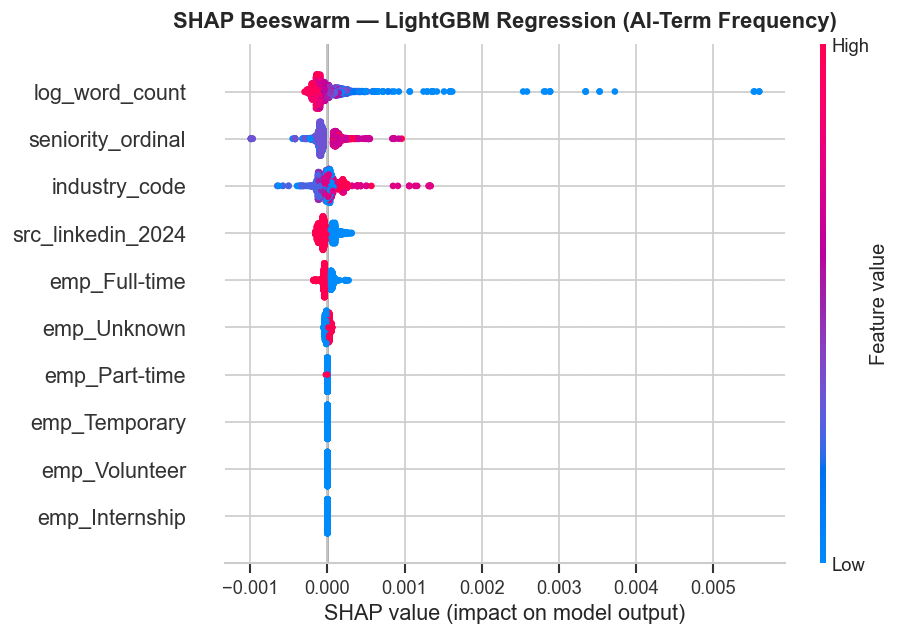

Figure 14 saved.


In [18]:
# ── SHAP for regression model ─────────────────────────────────────────────────
explainer_reg = shap.TreeExplainer(lgb_reg)
shap_vals_reg = explainer_reg.shap_values(X_lgbm_test)

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(
    shap_vals_reg, X_lgbm_test,
    feature_names=LGBM_FEATURES,
    plot_type='dot',
    show=False,
    max_display=15,
)
plt.title('SHAP Beeswarm — LightGBM Regression (AI-Term Frequency)',
          fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig14_shap_beeswarm_regression.png')
plt.show()
print('Figure 14 saved.')

## 6. Model Comparison

In [19]:
comparison = pd.DataFrame([
    {'Model': 'OLS (HC3)',                       'Task': 'Regression',     'Test R²': round(ols_r2, 4),  'Test RMSE': round(ols_rmse, 6),   'Test AUC': '—',                    'Test F1': '—'},
    {'Model': 'LightGBM',                        'Task': 'Regression',     'Test R²': round(lgb_r2, 4),  'Test RMSE': round(lgb_rmse, 6),   'Test AUC': '—',                    'Test F1': '—'},
    {'Model': 'Logistic (HC3, dense only)',      'Task': 'Classification', 'Test R²': '—', 'Test RMSE': '—', 'Test AUC': round(logit_auc, 4),     'Test F1': round(logit_f1, 4)},
    {'Model': 'LightGBM (dense only)',           'Task': 'Classification', 'Test R²': '—', 'Test RMSE': '—', 'Test AUC': round(lgb_auc, 4),       'Test F1': round(lgb_f1, 4)},
    {'Model': 'Logistic + TF-IDF(2000)',         'Task': 'Classification', 'Test R²': '—', 'Test RMSE': '—', 'Test AUC': round(log_tfidf_auc, 4), 'Test F1': round(log_tfidf_f1, 4)},
    {'Model': 'LightGBM + TF-IDF(2000)',         'Task': 'Classification', 'Test R²': '—', 'Test RMSE': '—', 'Test AUC': round(lgb_tfidf_auc, 4), 'Test F1': round(lgb_tfidf_f1, 4)},
    {'Model': 'Ensemble (LGB + Logit) + TFIDF',  'Task': 'Classification', 'Test R²': '—', 'Test RMSE': '—', 'Test AUC': round(ens_auc, 4),       'Test F1': round(best_f1, 4)},
])

comparison.to_csv(PROC_DIR / 'model_comparison.csv', index=False)
print('Model comparison (Test F1 for classification uses tuned threshold for the Ensemble winner):')
display(comparison)


Model comparison (Test F1 for classification uses tuned threshold for the Ensemble winner):


,Model,Task,Test R²,Test RMSE,Test AUC,Test F1
0,OLS (HC3),Regression,0.0393,0.00162,—,—
1,LightGBM,Regression,0.0792,0.001586,—,—
2,"Logistic (HC3, dense only)",Classification,—,—,0.6985,0.0192
3,LightGBM (dense only),Classification,—,—,0.6865,0.0
4,Logistic + TF-IDF(2000),Classification,—,—,0.9011,0.6123
5,LightGBM + TF-IDF(2000),Classification,—,—,0.9177,0.6961
6,Ensemble (LGB + Logit) + TFIDF,Classification,—,—,0.9166,0.6948


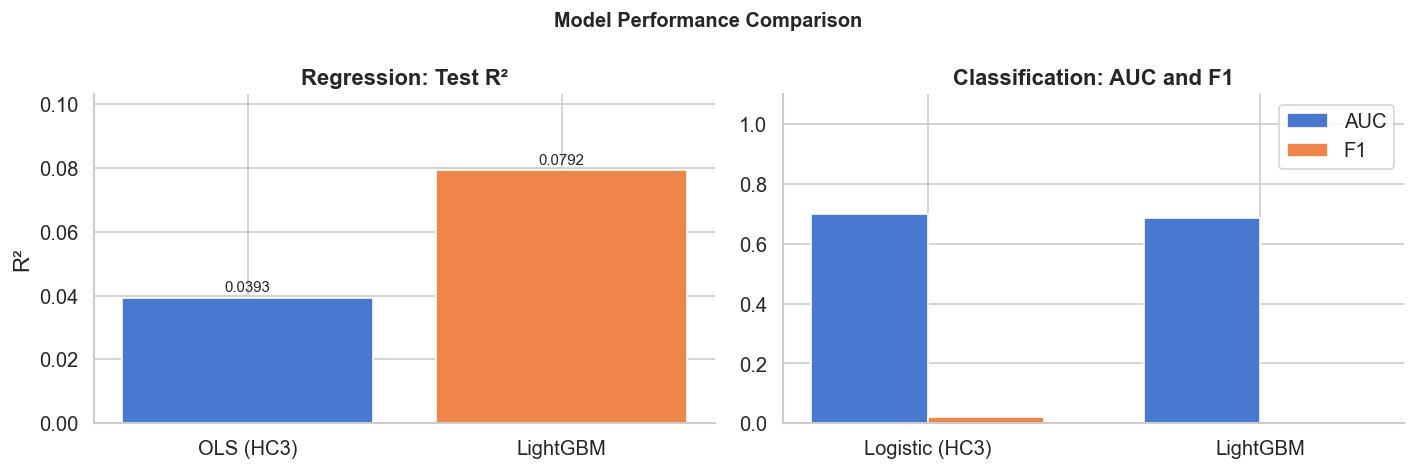

Figure 15 saved.


In [20]:
# ── Performance bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Regression: R²
reg_df = pd.DataFrame({
    'Model': ['OLS (HC3)', 'LightGBM'],
    'R²':    [ols_r2, lgb_r2],
})
axes[0].bar(reg_df['Model'], reg_df['R²'],
            color=sns.color_palette('muted', n_colors=2), edgecolor='white')
axes[0].set_ylim(0, max(reg_df['R²'].max() * 1.3, 0.1))
axes[0].set_title('Regression: Test R²', fontweight='bold')
axes[0].set_ylabel('R²')
for i, v in enumerate(reg_df['R²']):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)

# Classification: AUC
clf_df = pd.DataFrame({
    'Model': ['Logistic (HC3)', 'LightGBM'],
    'AUC':   [logit_auc, lgb_auc],
    'F1':    [logit_f1, lgb_f1],
})
x = np.arange(len(clf_df))
width = 0.35
axes[1].bar(x - width / 2, clf_df['AUC'], width, label='AUC',
            color=sns.color_palette('muted')[0], edgecolor='white')
axes[1].bar(x + width / 2, clf_df['F1'], width, label='F1',
            color=sns.color_palette('muted')[1], edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(clf_df['Model'])
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Classification: AUC and F1', fontweight='bold')
axes[1].legend()

fig.suptitle('Model Performance Comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig15_model_comparison.png')
plt.show()
print('Figure 15 saved.')

## 7. LightGBM Native Feature Importance

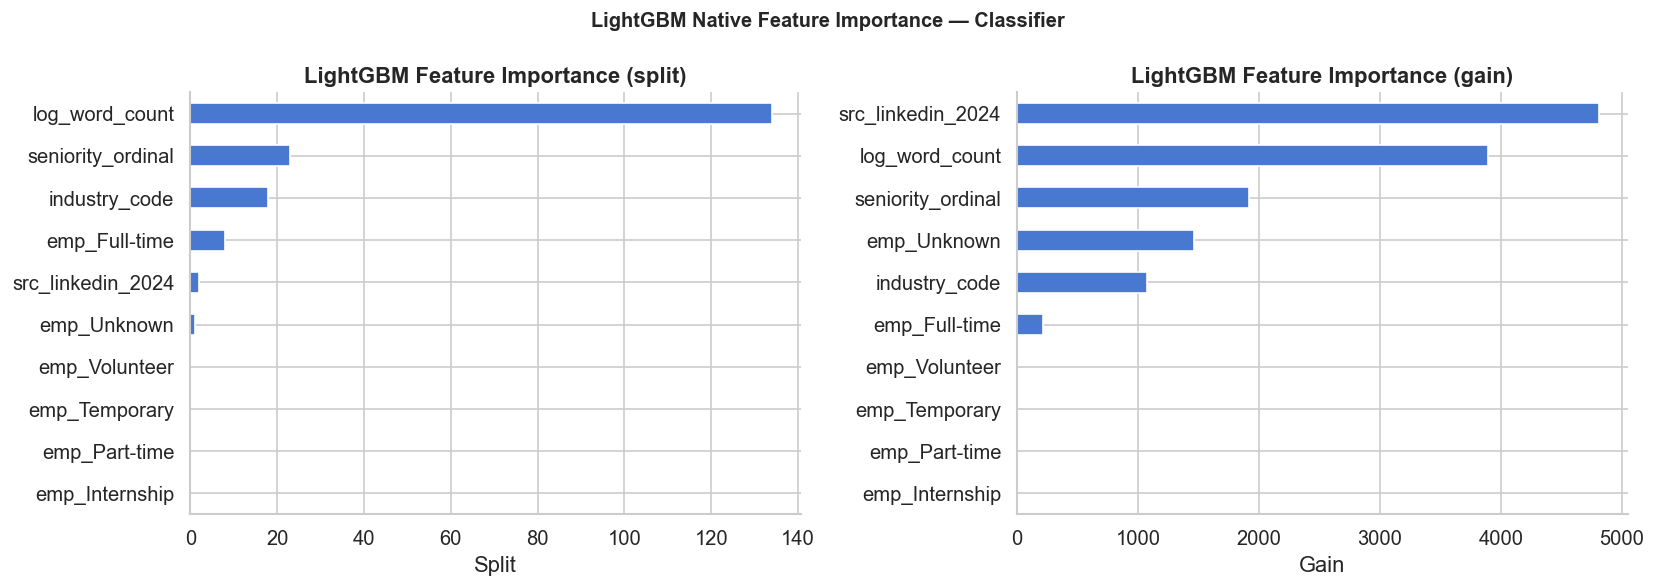

Figure 16 saved.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, importance_type in zip(axes, ['split', 'gain']):
    fi = pd.Series(
        lgb_clf.booster_.feature_importance(importance_type=importance_type),
        index=LGBM_FEATURES,
    ).sort_values(ascending=True).tail(15)

    fi.plot.barh(ax=ax, color=sns.color_palette('muted')[0], edgecolor='white')
    ax.set_title(f'LightGBM Feature Importance ({importance_type})', fontweight='bold')
    ax.set_xlabel(importance_type.capitalize())

fig.suptitle('LightGBM Native Feature Importance — Classifier', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig16_lgbm_feature_importance.png')
plt.show()
print('Figure 16 saved.')

## 8. Confusion Matrix (LightGBM Classifier)

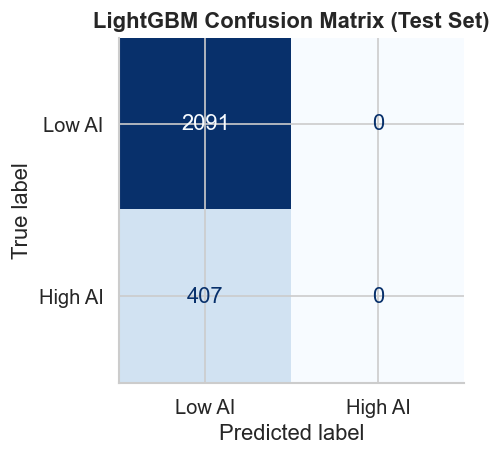

Figure 17 saved.


In [22]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_bin_test, y_pred_lgb)
disp = ConfusionMatrixDisplay(cm, display_labels=['Low AI', 'High AI'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('LightGBM Confusion Matrix (Test Set)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig17_confusion_matrix_lgbm.png')
plt.show()
print('Figure 17 saved.')

## 9. Observations and Interpretation

### Feature importance across models
- The three views — logistic coefficients, SHAP, and LightGBM's native split/gain — agree on which features carry the signal: **posting length, seniority, and the source/year indicator** (`src_linkedin_2024`) sit near the top, with **industry** (Patent/IP and Pharma especially) close behind. They differ mainly in ordering: count-based "split" importance favors posting length, while "gain" and SHAP favor the source/year flag (used in few splits but each highly decisive).
- The single largest-magnitude effect is `src_linkedin_2024`, but it tracks the 2024-vs-2026 data-source split rather than a real industry signal, so the substantive story is read off industry, seniority, and length.
- Relative to farming/forestry, the odds of an AI-exposed posting are ~2.9× higher in Patent/IP, ~2.1× in Pharma, ~1.7× in insurance, and ~1.4× in legal services (all p < 0.05); more senior and longer postings are also more exposed.

### Model performance
- Out-of-sample R² is low for both regressors (OLS 0.039, LightGBM 0.079): metadata alone explains under 8% of the variation in AI-term frequency.
- On dense features the classifiers are near-useless at the 0.5 cutoff (F1 ≈ 0) given the 16.3% positive rate — they default to predicting "Low AI."
- Adding 2,000 TF-IDF text features (AI terms masked, fit on train only) lifts AUC to ~0.92 and F1 to ~0.70 (AUC-PR 0.76). The predictive signal lives in the **description text**, not the metadata — which motivates the language-model approach in notebooks 05–06.

### Caveats
- `year` is confounded with the data source (2024 = external Kaggle archive, 2026 = own scrape), so this is a descriptive two-snapshot comparison, not a causal time trend.
- Keyword flags do not distinguish required mentions ("must know LLMs") from incidental ones ("we do not use AI"); the zero-shot and LLM labelers in later notebooks address this.

In [23]:
print('All figures saved to:', FIG_DIR.resolve())
print('Model comparison saved to:', PROC_DIR / 'model_comparison.csv')
print('\nNotebook 4 complete.')

All figures saved to: /Users/PeakViprakasit/QSS45_Final_Project/output/figures
Model comparison saved to: data/processed/model_comparison.csv

Notebook 4 complete.
